Training Parameters with icrn
=============================

This notebook will walk through how parameters to icrns can be trained. We will show how rate constants and initial concentrations can be trained with basic gradient descent.

# Setting up icrn

In [ ]:
!pip install icrn

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from icrn import (
    MassActionReaction,
    many_index_symbols,
    many_rate_constants,
    many_species,
    solve_well_mixed,
)

We will use the same ICRN from "Getting Started with icrn".

In [2]:
A, B = many_species("A, B")
alpha = many_rate_constants("alpha")
i, j = many_index_symbols("i, j", 5)

example_rxns = [
    MassActionReaction(0, A[i], alpha[i]),  # production of A
    MassActionReaction(A[j], 0, 1.0),  # degradation of A
]

# Training Parameters with icrn

[jax](https://docs.jax.dev/en/latest/index.html) is a machine learning library, and icrn simulations are written to be compatible with other jax functions. Consider following a tutorial on jax to explore the capabilities of jax.

In [3]:
import jax
import jax.numpy as jnp

times = jnp.linspace(0.0, 10.0, 1001)
dt = 1e-3

Because icrn is compatible with jax, we can find partial gradients for tensor (jax array) inputs. So, both rate constants and initial concentrations of simulations can be trained. By extension, we can also train diffusion constants in the reaction diffusion case.

## Training Rate Constants

In this section, we are going to train the alpha rate constant to produce the following steady state concentrations.

$$ [A]_i^{\text{steady state}} = 1 + i $$

Training with icrn will often have the following structure.

*   The forward function simulates the ICRN, taking the parameters that are subject to training as input. The specification of the system is a function of the training parameters. So, the time-evolution of the chemical system can be thought of as a function of the parameters.
*   The loss_fn function takes the results of the forward function and assigns a score to how close it is to the desired behavior. The loss can be computed based on the history of concentrations from the forward function.
*   The param_update function performs basic gradient descent by computing the gradient of the loss function with respect to the parameters subject to optimization. The function also returns the value of the loss.

`jax.jit` and `jax.value_and_grad` are commonly used jax features. Refer to jax documentation for more information.

In [4]:
def RC_forward(params):
    conc_vals = {A: jnp.ones(5)}
    rate_constant_vals = {alpha: params}

    concs_hist = solve_well_mixed(
        example_rxns,
        conc_vals,
        rate_constant_vals,
        times,
        dt,
        reaction_solver="Euler",
    )

    return concs_hist


def RC_loss_fn(params):
    concs_hist = RC_forward(params)
    final_concs = jax.tree.map(
        lambda x: x[-1], concs_hist
    )  # take the last time point

    target_concs = 1.0 + jnp.arange(5)
    sq_err = (final_concs[A] - target_concs) ** 2
    return jnp.sum(sq_err)


@jax.jit  # speeds up computations using just-in-time compilation
def RC_param_update(params, lr):
    loss_val, grad = jax.value_and_grad(RC_loss_fn)(params)
    params -= grad * lr
    return loss_val, params

Now, we will write a training loop that updates the weights. We will initialize alpha to be a tensor of all ones.

In [5]:
train_steps = 100
alpha_param = jnp.ones(5)  # initialize from all ones

for train_step in range(train_steps):
    loss, alpha_param = RC_param_update(alpha_param, lr=0.05)
    print(f"step {train_step}, param {alpha_param}, loss {loss}")

step 0, param [1.        1.0999956 1.1999913 1.2999885 1.3999826], loss 30.0
step 1, param [1.        1.189998  1.3799902 1.5699866 1.7599747], loss 24.30129623413086
step 2, param [1.        1.2710007 1.5419905 1.8129859 2.08397  ], loss 19.684226989746094
step 3, param [1.        1.3439039 1.687792  2.0316846 2.3755739], loss 15.944707870483398
step 4, param [1.        1.4095174 1.8190145 2.2285192 2.63802  ], loss 12.915556907653809
step 5, param [1.        1.4685695 1.9371145 2.4056711 2.874221 ], loss 10.461684226989746
step 6, param [1.        1.5217165 2.0434048 2.5651093 3.0868027], loss 8.474039077758789
step 7, param [1.        1.5695486 2.1390717 2.7086048 3.278126 ], loss 6.8641462326049805
step 8, param [1.        1.612598  2.2251728 2.8377523 3.450318 ], loss 5.5600104331970215
step 9, param [1.        1.6513425 2.3026643 2.9539847 3.605292 ], loss 4.5036468505859375
step 10, param [1.        1.686213  2.3724074 3.058594  3.74477  ], loss 3.6479854583740234
step 11, param

Plotting the trajectory using the trained parameters shows the desired behavior.

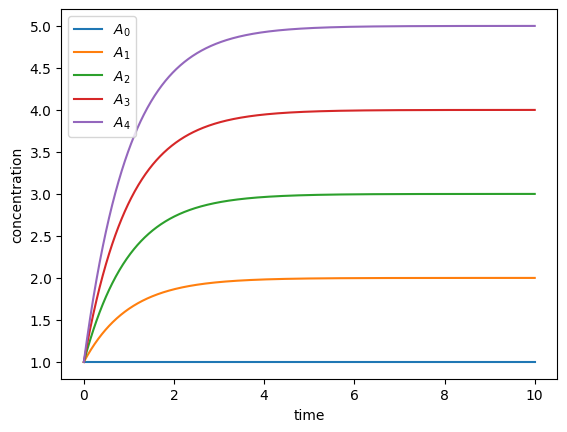

In [6]:
concs_hist = RC_forward(alpha_param)

for idx in range(5):
    plt.plot(times, concs_hist[A][:, idx], label=f"$A_{idx}$")
plt.legend()
plt.xlabel("time")
plt.ylabel("concentration")
plt.show()

# Training Initial Concentrations

Now imagine that we want to train the initial concentrations of A so that the concentrations reach the same steady state but reach specific concentrations before steady state. The flexibility of jax allows us to optimize any tensor backed object using gradient descent methods.

We set up the following functions in a fashion similar to the previous example of training rate constants.

In [ ]:
def IC_forward(params):
    conc_vals = {A: params}
    rate_constant_vals = {alpha: 1.0 + jnp.arange(5)}

    concs_hist = solve_well_mixed(
        example_rxns,
        conc_vals,
        rate_constant_vals,
        times,
        dt,
        reaction_solver="Euler",
    )
    final_concs = {s: hist[-1] for s, hist in concs_hist.items()}
    return final_concs, concs_hist


def IC_loss_fn(params):
    _, concs_hist = IC_forward(params)
    # target concentrations at time 2.5 (index 250 of 0..10 in 1001 steps)
    quarter_target_concs = jnp.array([1.1, 3.3, 5.2, 4.2, 4.8])
    return jnp.sum((concs_hist[A][250] - quarter_target_concs) ** 2)


@jax.jit  # speeds up computations using just-in-time compilation
def IC_param_update(params, lr):
    loss_val, grad = jax.value_and_grad(IC_loss_fn)(params)
    params -= lr * grad
    return loss_val, params

In [8]:
train_steps = 100
A_init = jnp.ones(5)

for train_step in range(train_steps):
    loss, A_init = IC_param_update(A_init, lr=1e1)
    print(f"step {train_step}, param {A_init}, loss {loss}")

step 0, param [1.1639646 3.265965  4.876073  1.731195  1.2097607], loss 7.723438739776611
step 1, param [1.3058898 5.227331  8.231114  2.3641026 1.391325 ], loss 5.786584854125977
step 2, param [ 1.4287348  6.925042  11.135162   2.9119318  1.5484842], loss 4.335458755493164
step 3, param [ 1.5350683  8.394553  13.648841   3.3861206  1.6845198], loss 3.248234748840332
step 4, param [ 1.6271069  9.666525  15.824626   3.7965698  1.8022703], loss 2.433657646179199
step 5, param [ 1.7067744 10.767512  17.707949   4.1518435  1.9041853], loss 1.8233678340911865
step 6, param [ 1.7757325 11.720509  19.338099   4.45936    1.9923974], loss 1.3661056756973267
step 7, param [ 1.8354218 12.545402  20.749126   4.725541   2.0687547], loss 1.0235258340835571
step 8, param [ 1.8870869 13.259407  21.970484   4.955944   2.1348495], loss 0.7668523192405701
step 9, param [ 1.9318072 13.877436  23.027653   5.155373   2.1920602], loss 0.5745382905006409
step 10, param [ 1.9705151 14.412382  23.942713   5.328

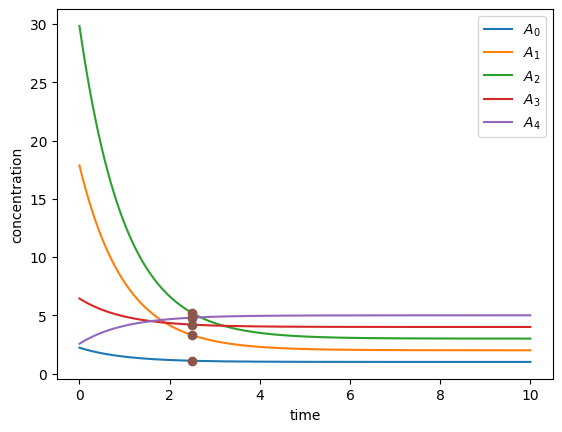

In [ ]:
_, concs_hist = IC_forward(A_init)

for idx in range(5):
    plt.plot(times, concs_hist[A][:, idx], label=f"$A_{idx}$")

plt.plot(
    np.repeat(2.5, 5),
    [1.1, 3.3, 5.2, 4.2, 4.8],
    marker="o",
    linestyle="",
)
plt.legend()
plt.xlabel("time")
plt.ylabel("concentration")
plt.show()